In [11]:
# Data handling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv(r"C:\Users\SAKTHI\Desktop\myproject\EMI Predict AI\data\emi_prediction_dataset.csv")

C:\Users\SAKTHI\AppData\Local\Temp\ipykernel_17724\3187611280.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\SAKTHI\Desktop\myproject\EMI Predict AI\data\emi_prediction_dataset.csv")


In [13]:
data_info = pd.DataFrame(
    {
        'Data_column':df.columns,
        'Total_Rows': len(df),
        'Data_count':df.count(),
        'Data_null':df.isnull().sum(),
        'Data_missing_percentage': (df.isnull().sum() / len(df)) * 100,
        'Data_type':df.dtypes,
        "sample_unique_values": [
        df[col].unique()[:10] for col in df.columns
    ]
    }
).reset_index(drop=True)


data_info

,Data_column,Total_Rows,Data_count,Data_null,Data_missing_percentage,Data_type,sample_unique_values
0,age,404800,404800,0,0.000000,object,"[38, 58, 48, 32, 27, 47, 37, 31, 59, 49]"
1,gender,404800,404800,0,0.000000,object,"[Female, Male, female, male, M, MALE, F, FEMALE]"
2,marital_status,404800,404800,0,0.000000,object,"[Married, Single]"
3,education,404800,402396,2404,0.593874,object,"[Professional, Graduate, High School, Post Gra..."
4,monthly_salary,404800,404800,0,0.000000,object,"[82600, 21500, 86100, 66800, 57300, 38800, 271..."
5,employment_type,404800,404800,0,0.000000,object,"[Private, Government, Self-employed]"
6,years_of_employment,404800,404800,0,0.000000,float64,"[0.9, 7.0, 5.8, 2.2, 3.4, 5.0, 36.0, 12.9, 1.9..."
7,company_type,404800,404800,0,0.000000,object,"[Mid-size, MNC, Startup, Large Indian, Small]"
8,house_type,404800,404800,0,0.000000,object,"[Rented, Family, Own]"
9,monthly_rent,404800,402374,2426,0.599308,float64,"[20000.0, 0.0, 13500.0, 13100.0, 11700.0, 1760..."


In [14]:
for i in df.columns:
    print(f"{i} - {df[i].dtype} - Unique Count: {df[i].nunique()}")
    print(df[i].unique())
    print("-------------------------")

age - object - Unique Count: 33
[38 58 48 32 27 47 37 31 59 49 33 26 39 57 28 '58' '38' '48' '32' '27'
 '37' '33' '49' '31' '39' '47' '59' '57' '26' '28' '58.00.00' '38.00.00'
 '32.00.00']
-------------------------
gender - object - Unique Count: 8
['Female' 'Male' 'female' 'male' 'M' 'MALE' 'F' 'FEMALE']
-------------------------
marital_status - object - Unique Count: 2
['Married' 'Single']
-------------------------
education - object - Unique Count: 4
['Professional' 'Graduate' 'High School' 'Post Graduate' nan]
-------------------------
monthly_salary - object - Unique Count: 13662
['82600' '21500' '86100' ... '56779' '56280' '55905']
-------------------------
employment_type - object - Unique Count: 3
['Private' 'Government' 'Self-employed']
-------------------------
years_of_employment - float64 - Unique Count: 356
[ 0.9  7.   5.8  2.2  3.4  5.  36.  12.9  1.9  7.5  3.7  1.3  3.2  0.5
 26.   0.8  4.2  2.6  3.9  9.7  4.7  9.6  1.7  9.4  4.1  1.   7.6 16.
  2.5  1.6 17.1  6.6 12.6 

In [16]:
 # AGE CLEANING

df['age']=df['age'].astype(str)
df['age'] = df['age'].str.extract(r'(\d+)')


 # GENDER STANDARDIZATION

gender_map = {
    "female": "Female",
    "Female": "Female",
    "F": "Female",
    "FEMALE": "Female",
    "male": "Male",
    "Male": "Male",
    "M": "Male",
    "MALE": "Male"
    }

df['gender'] = df['gender'].replace(gender_map)

In [17]:
# NUMERIC TYPE FIXES

numeric_cols = ['age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents',
                'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses',
                'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount',
                'requested_tenure', 'max_monthly_emi']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [18]:
df.isnull().sum().sort_values(ascending=False)

bank_balance              4392
monthly_rent              2426
credit_score              2420
education                 2404
emergency_fund            2351
monthly_salary            1993
marital_status               0
years_of_employment          0
gender                       0
age                          0
employment_type              0
family_size                  0
house_type                   0
company_type                 0
dependents                   0
groceries_utilities          0
school_fees                  0
college_fees                 0
travel_expenses              0
current_emi_amount           0
existing_loans               0
other_monthly_expenses       0
emi_scenario                 0
requested_amount             0
requested_tenure             0
emi_eligibility              0
max_monthly_emi              0
dtype: int64

REFERENCE: HANDLING MISSING VALUES
-------------------------------------------------------------------------
| Data Type      | % Missing | Strategy   | Reasoning                   |
|----------------|-----------|------------|-----------------------------|
| Any            | < 3%      | dropna()   | Minimal data loss           |
| Num (Normal)   | 3-20%     | Mean       | Symmetrical data            |
| Num (Skewed)   | 3-20%     | Median     | Best for Finance/Outliers   |
| Categorical    | 3-20%     | Mode       | Most frequent category      |
| Any            | > 50%     | Drop Col   | Too much noise              |
-------------------------------------------------------------------------

In [19]:
total_rows = df.shape[0]


monthly_rent_percent=(((df["monthly_rent"].isnull().sum())/(total_rows))*100)
bank_balance_percent=(((df["bank_balance"].isnull().sum())/(total_rows))*100)
credit_score_percent=(((df["credit_score"].isnull().sum())/(total_rows))*100)
education_percent=(((df["education"].isnull().sum())/(total_rows))*100)
emergency_fund_percent=(((df["emergency_fund"].isnull().sum())/(total_rows))*100)

print('monthly_rent_percent :',monthly_rent_percent)
print('bank_balance_percent :',bank_balance_percent)
print('credit_score_percent :',credit_score_percent)
print('education_percent :',education_percent)
print('emergency_fund_percent :',emergency_fund_percent)


monthly_rent_percent : 0.5993083003952568
bank_balance_percent : 1.0849802371541504
credit_score_percent : 0.5978260869565217
education_percent : 0.5938735177865613
emergency_fund_percent : 0.5807806324110671


In [20]:
# numerical column missing value

numerical_columns = [
    'monthly_rent',
    'bank_balance',
    'credit_score',
    'emergency_fund',
    'monthly_salary'
]

for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)

# cateogrical column missing value
df["education"] = df["education"].fillna(df["education"].mode().iloc[0])

C:\Users\SAKTHI\AppData\Local\Temp\ipykernel_17724\3428014954.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\SAKTHI\AppData\Local\Temp\ipykernel_17724\3428014954.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [21]:
df.isnull().sum()

age                       0
gender                    0
marital_status            0
education                 0
monthly_salary            0
employment_type           0
years_of_employment       0
company_type              0
house_type                0
monthly_rent              0
family_size               0
dependents                0
school_fees               0
college_fees              0
travel_expenses           0
groceries_utilities       0
other_monthly_expenses    0
existing_loans            0
current_emi_amount        0
credit_score              0
bank_balance              0
emergency_fund            0
emi_scenario              0
requested_amount          0
requested_tenure          0
emi_eligibility           0
max_monthly_emi           0
dtype: int64

In [22]:
total_rows = df.shape[0]


monthly_rent_percent=(((df["monthly_rent"].isnull().sum())/(total_rows))*100)
bank_balance_percent=(((df["bank_balance"].isnull().sum())/(total_rows))*100)
credit_score_percent=(((df["credit_score"].isnull().sum())/(total_rows))*100)
education_percent=(((df["education"].isnull().sum())/(total_rows))*100)
emergency_fund_percent=(((df["emergency_fund"].isnull().sum())/(total_rows))*100)

print('monthly_rent_percent :',monthly_rent_percent)
print('bank_balance_percent :',bank_balance_percent)
print('credit_score_percent :',credit_score_percent)
print('education_percent :',education_percent)
print('emergency_fund_percent :',emergency_fund_percent)


monthly_rent_percent : 0.0
bank_balance_percent : 0.0
credit_score_percent : 0.0
education_percent : 0.0
emergency_fund_percent : 0.0


### Data Preprocessing

OUTLIER DETECTION

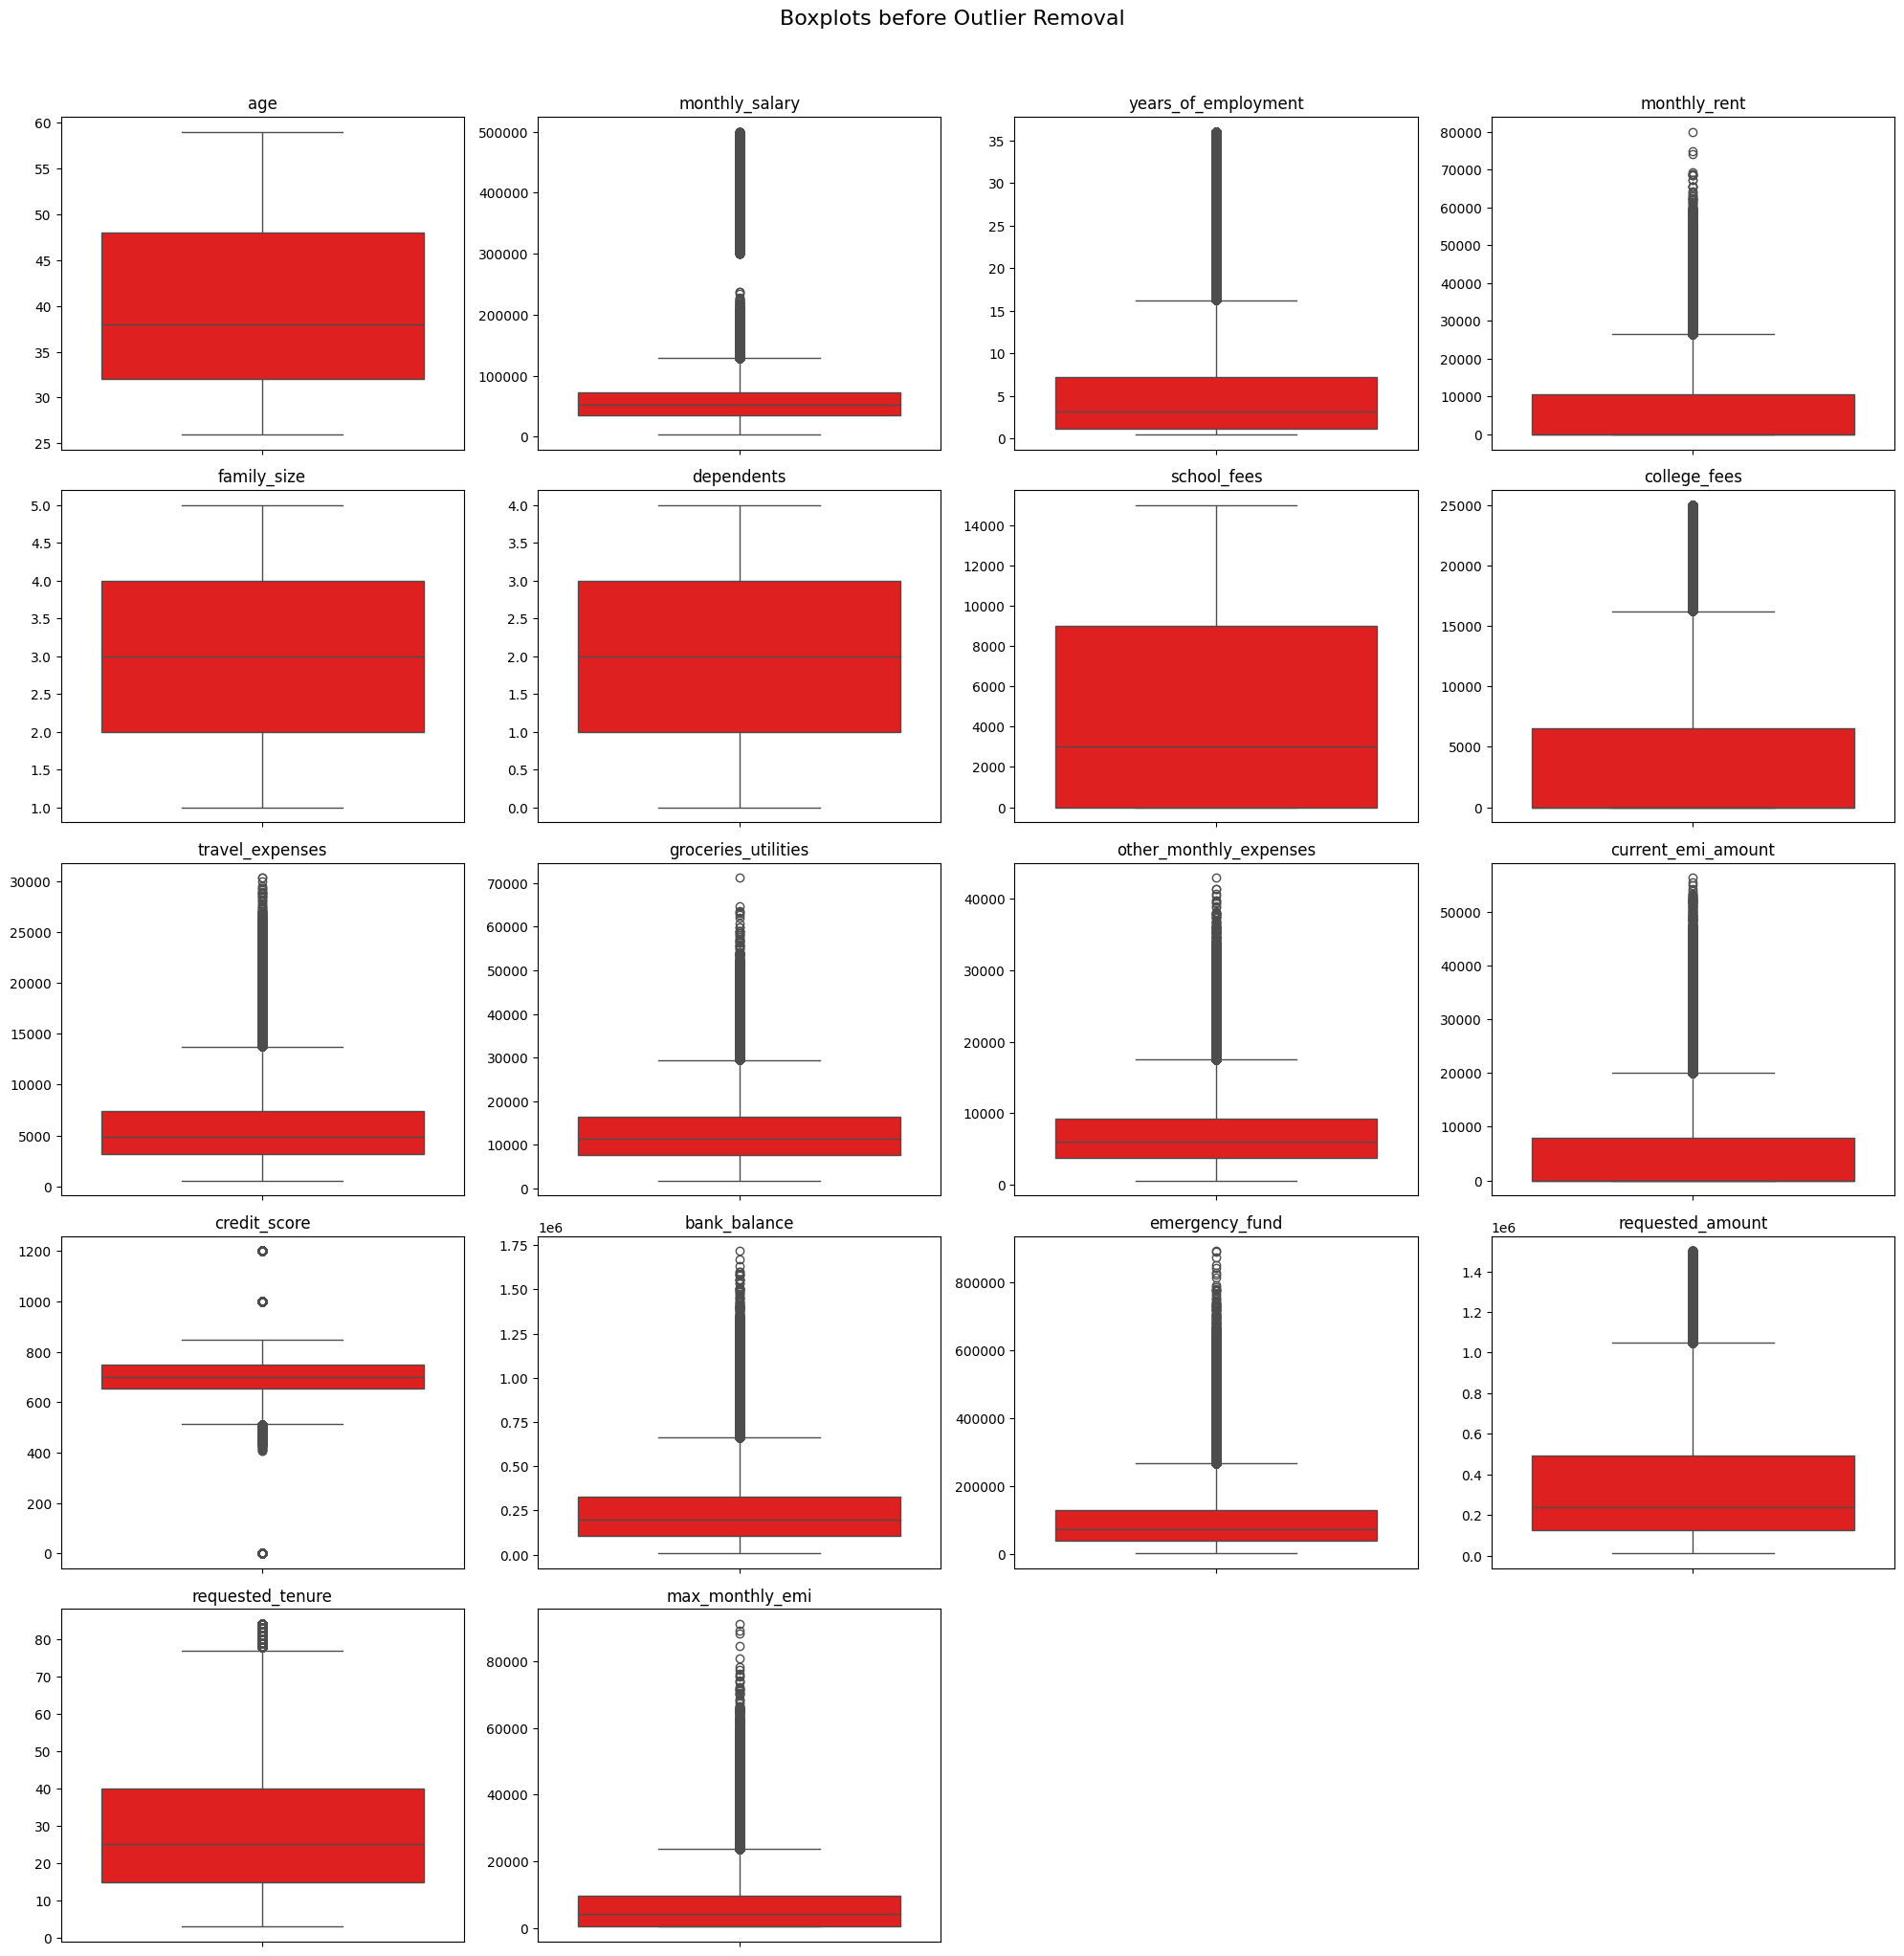

In [23]:
import math
numerical = ['age', 'monthly_salary', 'years_of_employment', 'monthly_rent',
    'family_size', 'dependents', 'school_fees', 'college_fees',
    'travel_expenses', 'groceries_utilities', 'other_monthly_expenses',
    'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund',
    'requested_amount', 'requested_tenure', 'max_monthly_emi']

cols = 4
rows = math.ceil(len(numerical) / cols)

plt.figure(figsize=(20, rows * 4))
plt.suptitle("Boxplots before Outlier Removal", fontsize=16, y=1.02)

for i, col in enumerate(numerical):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[col], color='red')
    plt.title(col)
    plt.ylabel("")

plt.tight_layout()
plt.show()

credit_score: 5840 outliers (1.44%)
requested_tenure: 7730 outliers (1.91%)


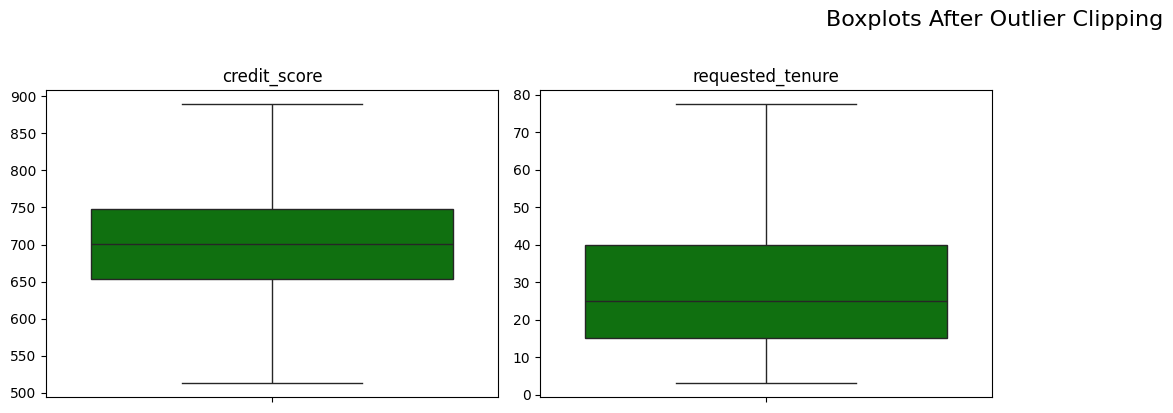

In [24]:
numerical = ['credit_score', 'requested_tenure']

# Function to handle outliers with IQR clipping
def clip_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Count outliers
    outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    percent_outliers = (outliers_count / len(df)) * 100
    print(f"{col}: {outliers_count} outliers ({percent_outliers:.2f}%)")
    # Clip
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    return df

# Apply to df (make a copy to preserve original)
for col in numerical:
    df = clip_outliers(df, col)

# Plot AFTER boxplots
cols = 4
rows = math.ceil(len(numerical) / cols)

plt.figure(figsize=(20, rows * 4))
plt.suptitle("Boxplots After Outlier Clipping", fontsize=16, y=1.02)

for i, col in enumerate(numerical):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[col], color='green')
    plt.title(col)
    plt.ylabel("")

plt.tight_layout()
plt.show()

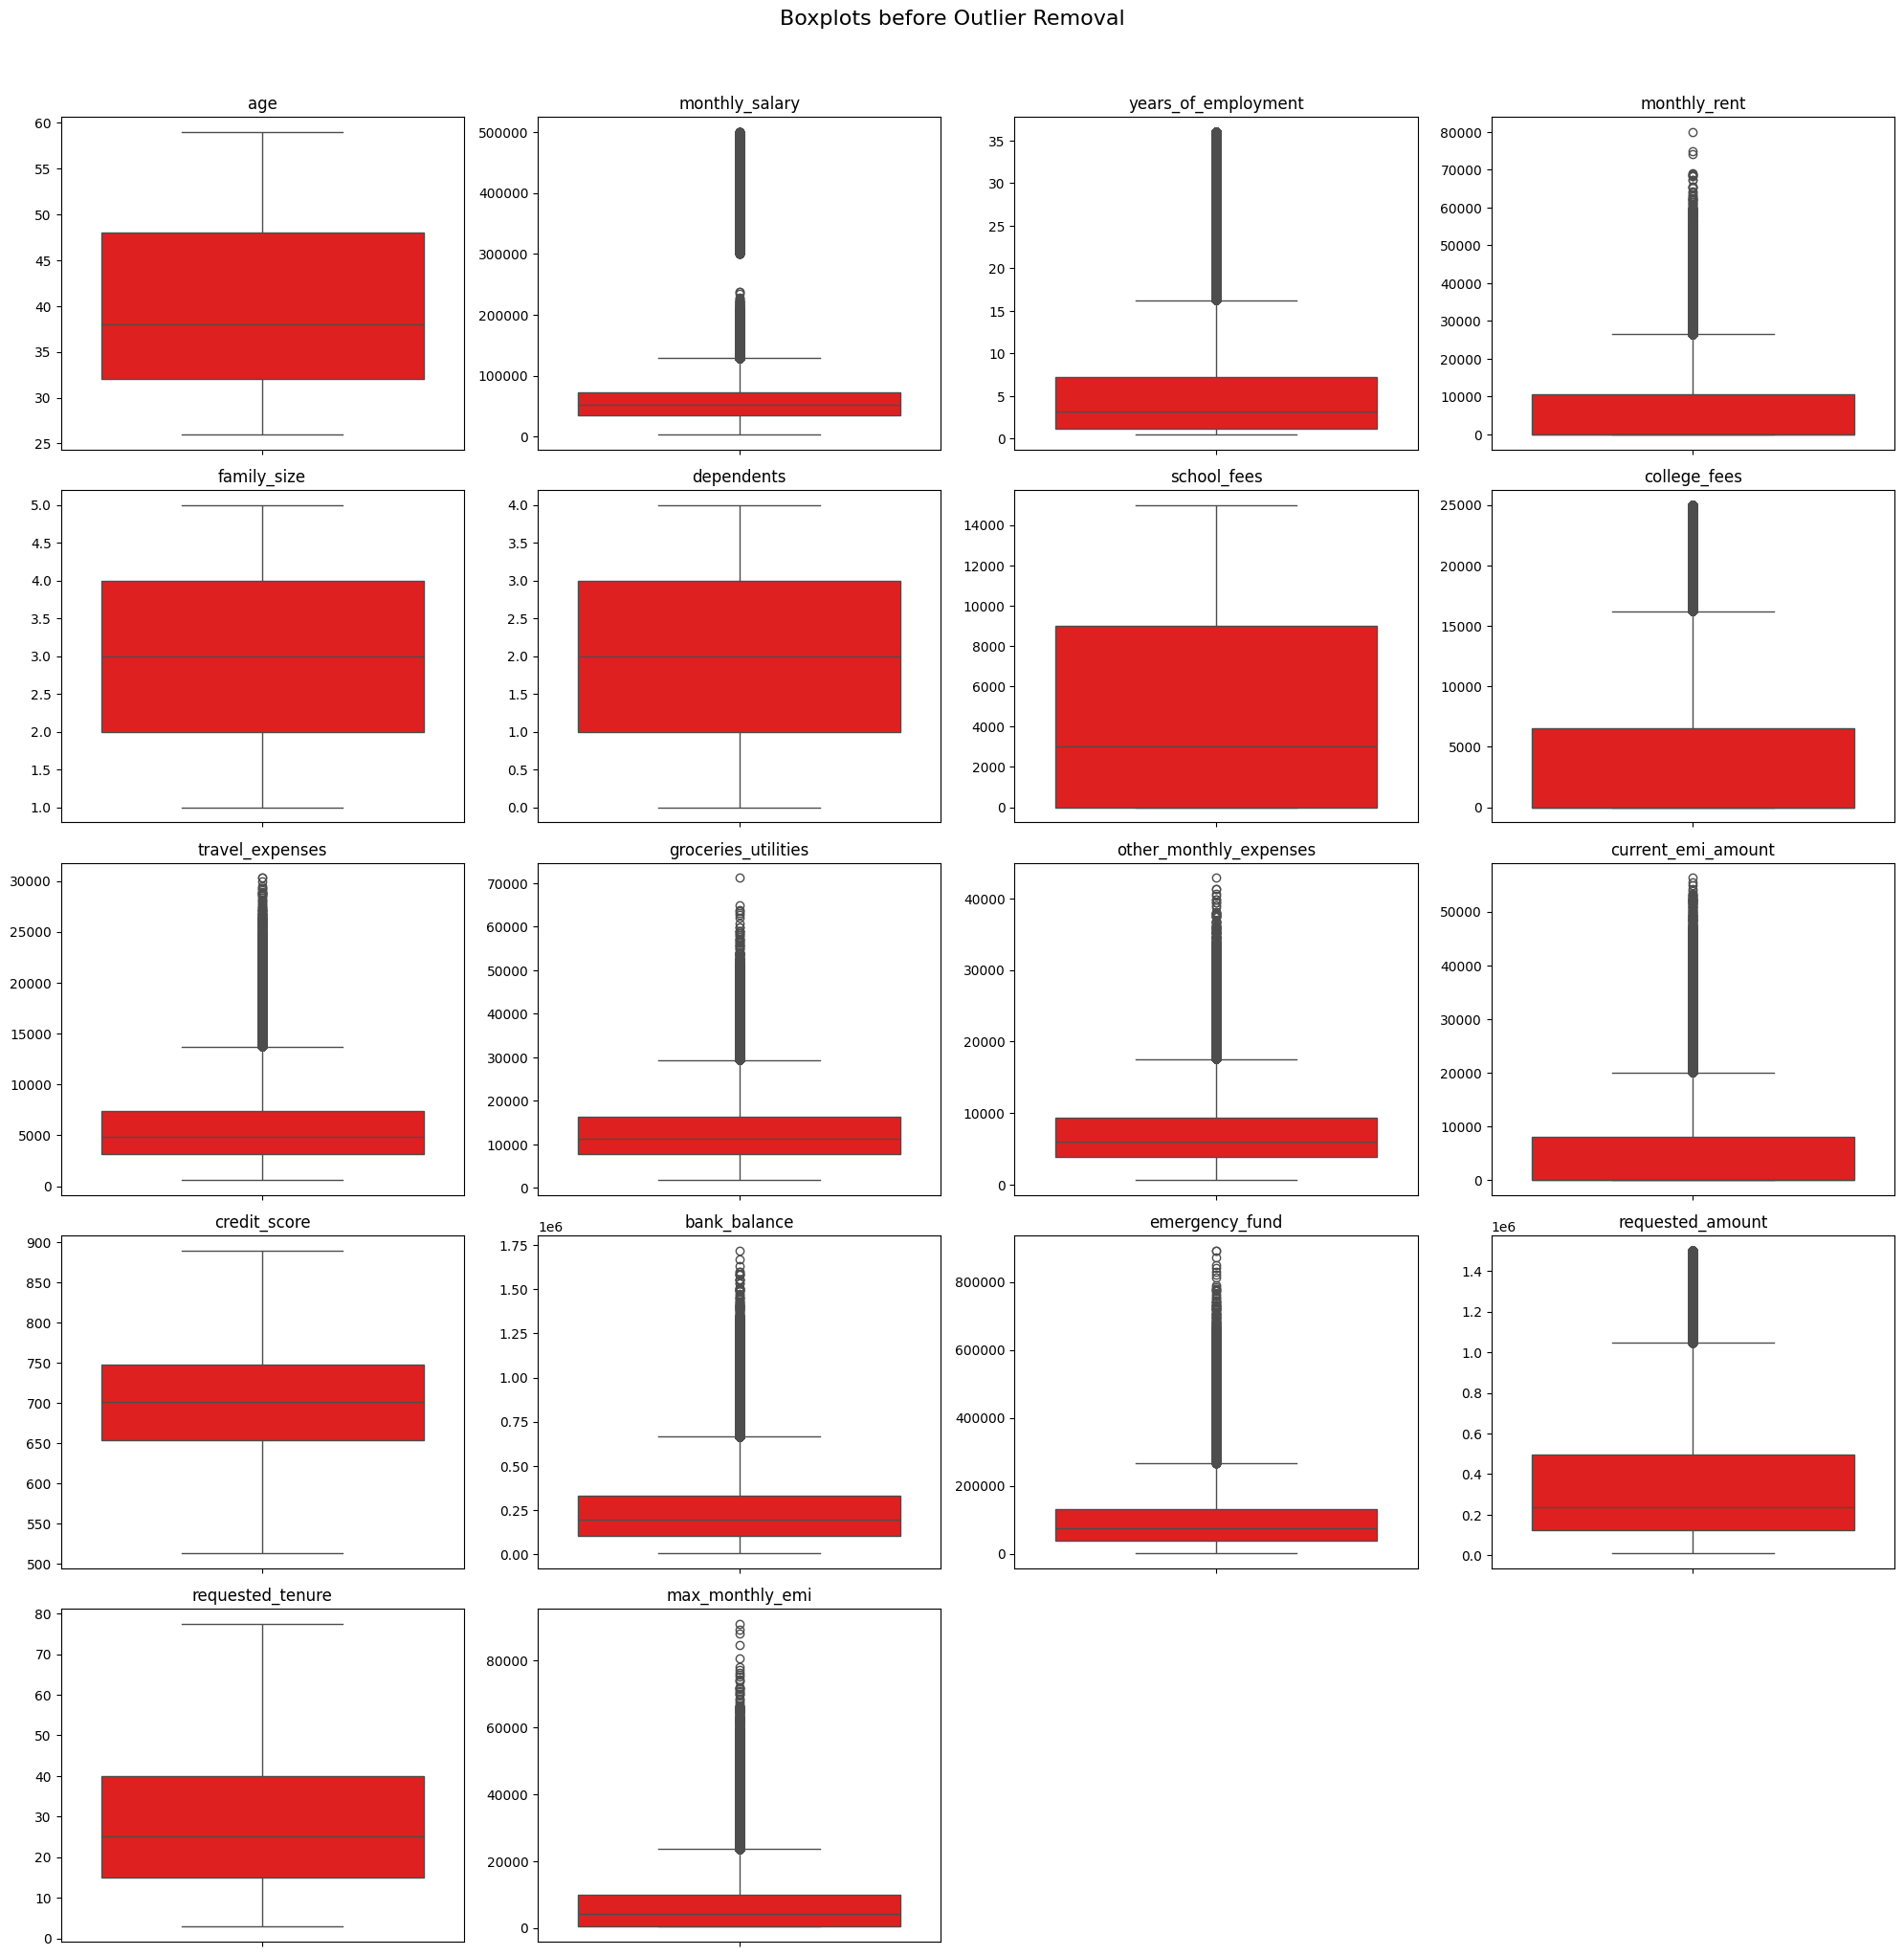

In [25]:
import math
numerical = ['age', 'monthly_salary', 'years_of_employment', 'monthly_rent',
    'family_size', 'dependents', 'school_fees', 'college_fees',
    'travel_expenses', 'groceries_utilities', 'other_monthly_expenses',
    'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund',
    'requested_amount', 'requested_tenure', 'max_monthly_emi']

cols = 4
rows = math.ceil(len(numerical) / cols)

plt.figure(figsize=(20, rows * 4))
plt.suptitle("Boxplots before Outlier Removal", fontsize=16, y=1.02)

for i, col in enumerate(numerical):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[col], color='red')
    plt.title(col)
    plt.ylabel("")

plt.tight_layout()
plt.show()

***Target Variable Analysis***

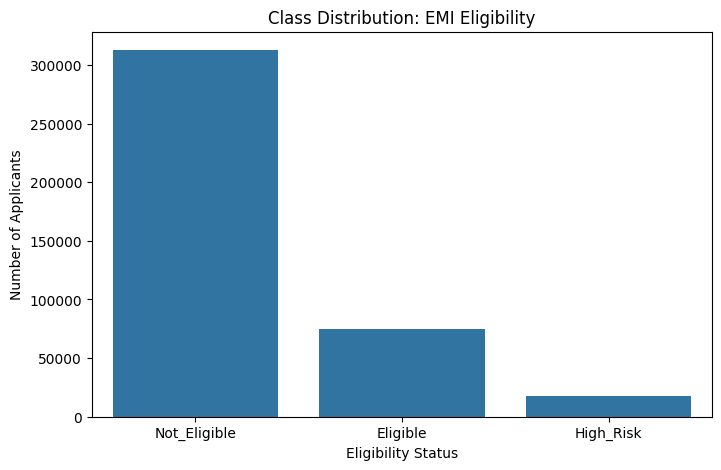

In [26]:
# For Classification

emi_eligible = df['emi_eligibility'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(emi_eligible)
plt.title('Class Distribution: EMI Eligibility')
plt.xlabel('Eligibility Status')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)
plt.show()


<Axes: xlabel='max_monthly_emi', ylabel='Count'>

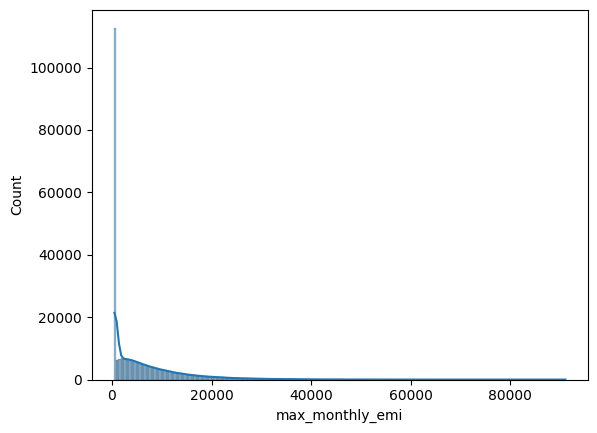

In [27]:
# For Regression
sns.histplot(df['max_monthly_emi'], kde=True)


**Correlation Analysis**

<Axes: >

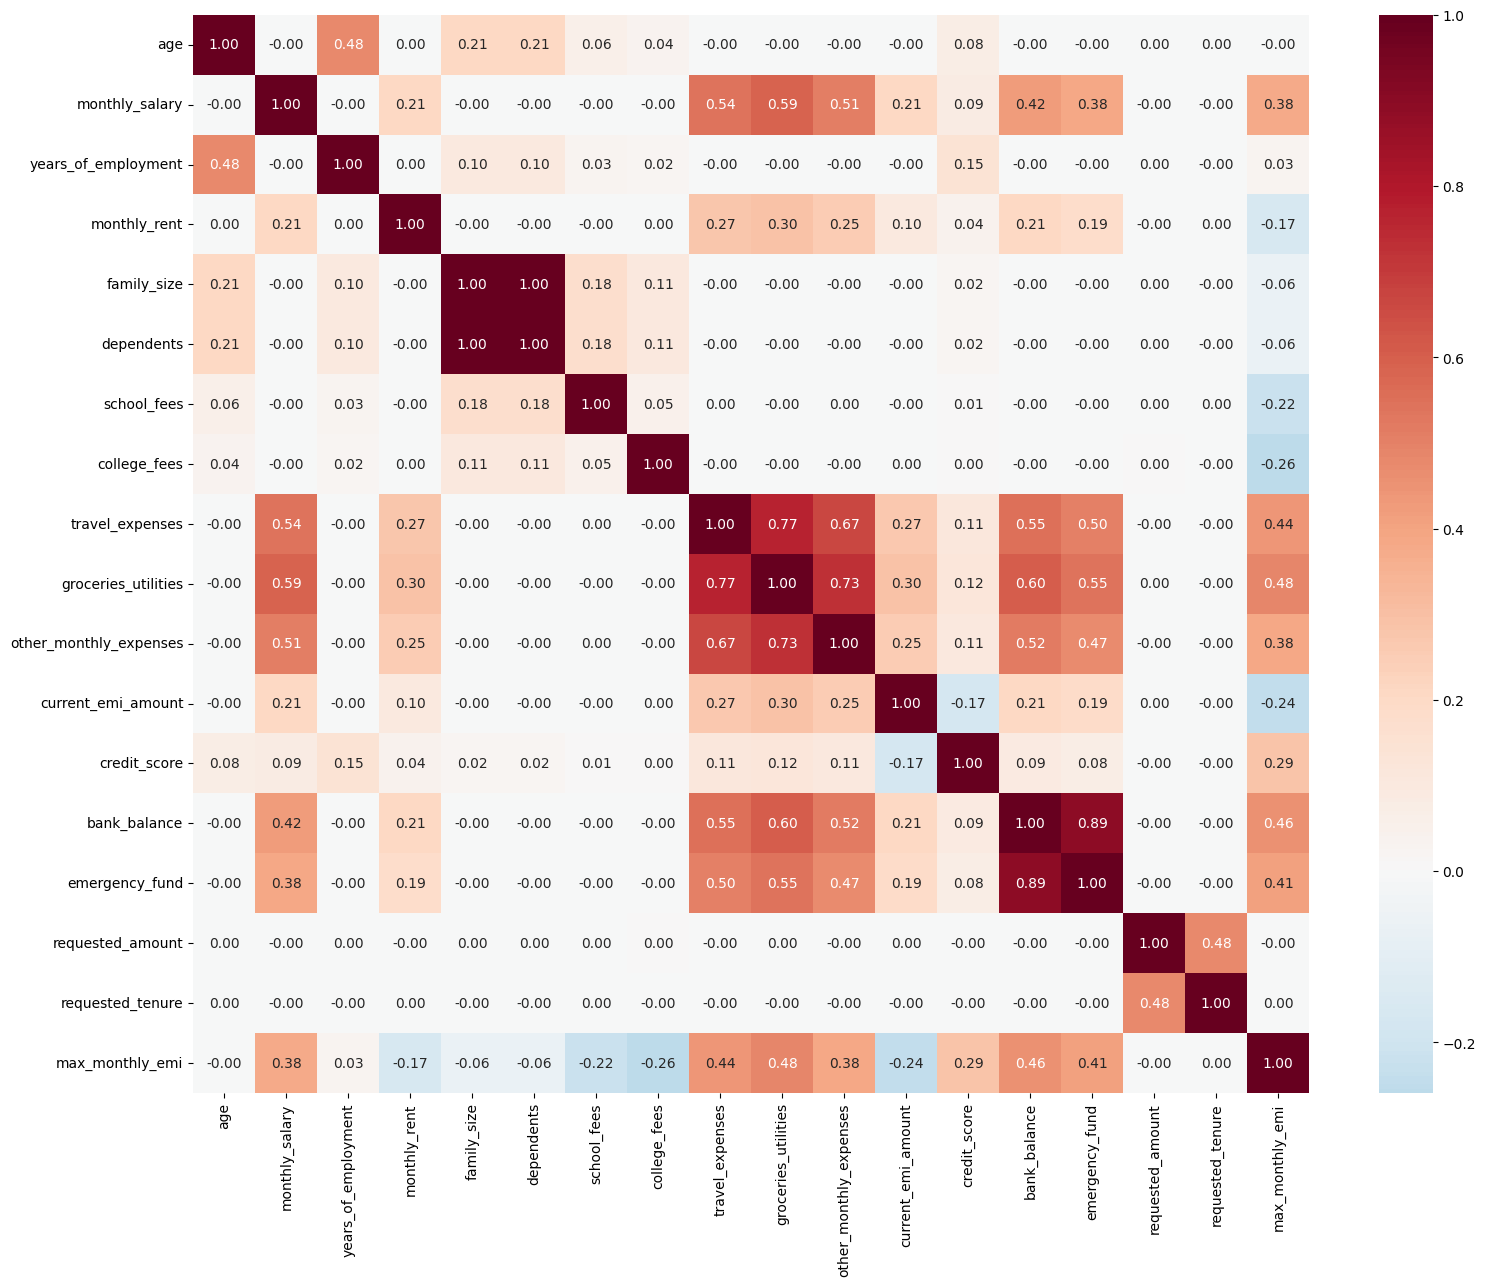

In [28]:
import seaborn as sns
plt.figure(figsize=(18, 14))
sns.heatmap(df.select_dtypes(include="number").corr(),
annot=True, fmt=".2f", cmap="RdBu_r", center=0)

In [29]:
df.corr(numeric_only=True)['max_monthly_emi'].sort_values(ascending=False)

# Since monthly_salary only has a 0.38 correlation with the EMI capacity, you should create more descriptive features, such as:

# Debt-to-Income Ratio: current_emi_amount / monthly_salary

# Disposable Income: monthly_salary - (all expense columns)

# Savings Rate: bank_balance / monthly_salary

max_monthly_emi           1.000000
groceries_utilities       0.484695
bank_balance              0.456028
travel_expenses           0.440948
emergency_fund            0.414036
other_monthly_expenses    0.382055
monthly_salary            0.378284
credit_score              0.286756
years_of_employment       0.028887
requested_tenure          0.001035
age                      -0.000855
requested_amount         -0.002034
dependents               -0.062266
family_size              -0.062266
monthly_rent             -0.169423
school_fees              -0.215234
current_emi_amount       -0.242434
college_fees             -0.258842
Name: max_monthly_emi, dtype: float64

**Bivariate Analysis**

*Salary vs EMI*

<Axes: xlabel='monthly_salary', ylabel='max_monthly_emi'>

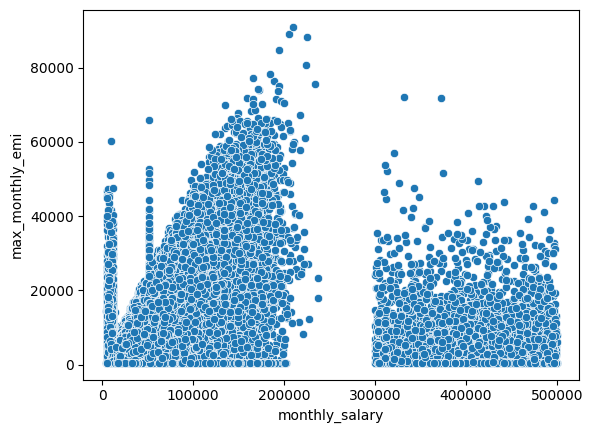

In [30]:
sns.scatterplot(x='monthly_salary', y='max_monthly_emi', data=df)

*Credit Score vs Eligibility*

<Axes: xlabel='credit_score', ylabel='emi_eligibility'>

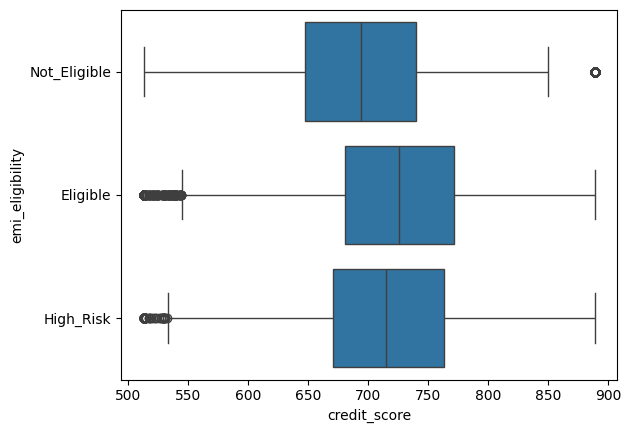

In [31]:
sns.boxplot(x=df['credit_score'],y=df['emi_eligibility'],data=df)

In [32]:
df.to_csv(r'C:\Users\SAKTHI\Desktop\myproject\EMI Predict AI\data\emi_prediction_dataset_eda.csv')